# HW 13: Intro to NLP, pt 2: Word2Vec

In [1]:
import re
import logging
import time

from bs4 import BeautifulSoup
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm_notebook

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
%load_ext pycodestyle_magic

In [4]:
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s',
                    level=logging.INFO)
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/anton/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/anton/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Import data

In [5]:
sentiment_data = pd.read_csv('data/train_data.tsv',
                             header=0, delimiter='\t', quoting=3)
train_data, test_data = train_test_split(sentiment_data,
                                         test_size=0.2, random_state=42)

In [6]:
sentiment_data.head()

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
3,"""3630_4""",0,"""It must be assumed that those who praised thi..."
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ..."


In [7]:
unlabeled_train_data = pd.read_csv('data/unlabeled_train_data.tsv',
                                   header=0, delimiter='\t', quoting=3)

In [8]:
tokenizer = nltk.data.load('tokenizers/punkt/english.pickle')

In [9]:
wordnet_lemmatizer = WordNetLemmatizer()

### Defining some helper functions

In [11]:
def series_to_wordlist(series, remove_stopwords=False):

    train_text0 = series.apply(lambda text:
                               BeautifulSoup(text, 'html.parser').get_text())
    train_text0 = train_text0.str.replace("[^a-zA-Z]", " ").str.lower()
    train_words = train_text0.str.split()

    if remove_stopwords:
        stops = set(stopwords.words("english"))   
        train_words = train_words.apply(lambda text:
                                    [wordnet_lemmatizer.lemmatize(t, 'v')
                                     for t in text if t not in stops])
    else:
        train_words = train_words.apply(lambda text:
                                    [wordnet_lemmatizer.lemmatize(t, 'v')
                                     for t in text])

    return train_words.values.ravel()

In [13]:
def series_to_sentences(series, remove_stopwords=False):

    train_text = series.apply(lambda text:
                              BeautifulSoup(text, 'html.parser').get_text())
    train_tokenize = train_text.str.strip().apply(tokenizer.tokenize)

    tt_df = pd.DataFrame(train_tokenize.values.tolist())
    tt_df = tt_df.replace("[^a-zA-Z]", " ", regex=True)
    tt_df = tt_df.applymap(lambda x: x.lower() if pd.notnull(x) else '')
    stops = set(stopwords.words("english"))

    if remove_stopwords:
        tt_df = tt_df.applymap(lambda x: [wordnet_lemmatizer.lemmatize(t, 'v')
                                          for t in x.split()
                                          if t not in stops])
    else:
        tt_df = tt_df.applymap(lambda x: [wordnet_lemmatizer.lemmatize(t, 'v')
                                          for t in x.split()])

    idx = [x != [] for x in tt_df.values.ravel()]
    return tt_df.values.ravel()[idx]

### Reviews go to sentences

In [14]:
%%time
print('Parsing sentences from training set')
sentences = series_to_sentences(train_data['review'])

Parsing sentences from training set
CPU times: user 44 s, sys: 662 ms, total: 44.7 s
Wall time: 44.7 s


In [15]:
len(sentences)

211859

In [16]:
%%time
print('Parsing sentences from unlabelled set')
unl_sentences = series_to_sentences(unlabeled_train_data['review'])

Parsing sentences from unlabelled set
CPU times: user 1min 18s, sys: 764 ms, total: 1min 19s
Wall time: 1min 19s


In [17]:
all_sentences = np.concatenate([sentences, unl_sentences])

In [18]:
print(all_sentences[0])

['this', 'movie', 'be', 'just', 'plain', 'dumb', 'from', 'the', 'cast', 'of', 'ralph', 'meeker', 'as', 'mike', 'hammer', 'to', 'the', 'fatuous', 'climax', 'the', 'film', 'be', 'an', 'exercise', 'in', 'wooden', 'predictability', 'mike', 'hammer', 'be', 'one', 'of', 'detective', 'fiction', 's', 'true', 'sociopaths']


### Defining the Word2Vec parameters

In [19]:
# Word vector dimensionality <- Seems to saturate at around 1000,
# so 500 is a tradeoff between the accuracy and computational time
num_features = 512
# Minimum word count <- doesn't affect anything much (apart from context)
min_word_count = 75
# Context window size <- increased to min_word_count
context = min_word_count
# Downsample setting for frequent words <- seems ok @1e-4
downsampling = 1e-4
# Seems slightly better when set to 0,
# at least with the other parameters chosen
skipgrams = 0

Training the model

In [20]:
# Initialize and train the model (this will take some time)
print("Training model...")
model = Word2Vec(
    all_sentences,
    workers=8,
    size=num_features,
    min_count=min_word_count,
    window=context,
    sample=downsampling,
    sg=skipgrams,
    seed=42
)

2019-11-24 15:17:42,797 : INFO : collecting all words and their counts
2019-11-24 15:17:42,798 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2019-11-24 15:17:42,840 : INFO : PROGRESS: at sentence #10000, processed 222391 words, keeping 14263 word types
2019-11-24 15:17:42,908 : INFO : PROGRESS: at sentence #20000, processed 449625 words, keeping 20255 word types


Training model...


2019-11-24 15:17:42,955 : INFO : PROGRESS: at sentence #30000, processed 670900 words, keeping 24523 word types
2019-11-24 15:17:43,015 : INFO : PROGRESS: at sentence #40000, processed 895417 words, keeping 28008 word types
2019-11-24 15:17:43,072 : INFO : PROGRESS: at sentence #50000, processed 1117514 words, keeping 30937 word types
2019-11-24 15:17:43,120 : INFO : PROGRESS: at sentence #60000, processed 1343308 words, keeping 33416 word types
2019-11-24 15:17:43,174 : INFO : PROGRESS: at sentence #70000, processed 1567228 words, keeping 35775 word types
2019-11-24 15:17:43,225 : INFO : PROGRESS: at sentence #80000, processed 1793101 words, keeping 37980 word types
2019-11-24 15:17:43,289 : INFO : PROGRESS: at sentence #90000, processed 2013742 words, keeping 39815 word types
2019-11-24 15:17:43,347 : INFO : PROGRESS: at sentence #100000, processed 2238377 words, keeping 41602 word types
2019-11-24 15:17:43,401 : INFO : PROGRESS: at sentence #110000, processed 2462482 words, keeping 

2019-11-24 15:17:46,767 : INFO : Loading a fresh vocabulary
2019-11-24 15:17:46,816 : INFO : effective_min_count=75 retains 9042 unique words (8% of original 105732, drops 96690)
2019-11-24 15:17:46,816 : INFO : effective_min_count=75 leaves 15930840 word corpus (95% of original 16608406, drops 677566)
2019-11-24 15:17:46,843 : INFO : deleting the raw counts dictionary of 105732 items
2019-11-24 15:17:46,846 : INFO : sample=0.0001 downsamples 440 most-common words
2019-11-24 15:17:46,846 : INFO : downsampling leaves estimated 6902713 word corpus (43.3% of prior 15930840)
2019-11-24 15:17:46,874 : INFO : estimated required memory for 9042 words and 512 dimensions: 41557032 bytes
2019-11-24 15:17:46,875 : INFO : resetting layer weights
2019-11-24 15:17:48,440 : INFO : training model with 8 workers on 9042 vocabulary and 512 features, using sg=0 hs=0 sample=0.0001 negative=5 window=75
2019-11-24 15:17:49,457 : INFO : EPOCH 1 - PROGRESS: at 8.93% examples, 608538 words/s, in_qsize 15, out_

2019-11-24 15:18:32,181 : INFO : worker thread finished; awaiting finish of 5 more threads
2019-11-24 15:18:32,195 : INFO : worker thread finished; awaiting finish of 4 more threads
2019-11-24 15:18:32,197 : INFO : worker thread finished; awaiting finish of 3 more threads
2019-11-24 15:18:32,198 : INFO : worker thread finished; awaiting finish of 2 more threads
2019-11-24 15:18:32,209 : INFO : worker thread finished; awaiting finish of 1 more threads
2019-11-24 15:18:32,211 : INFO : worker thread finished; awaiting finish of 0 more threads
2019-11-24 15:18:32,211 : INFO : EPOCH - 4 : training on 16608406 raw words (6904615 effective words) took 10.9s, 632195 effective words/s
2019-11-24 15:18:33,221 : INFO : EPOCH 5 - PROGRESS: at 8.98% examples, 617871 words/s, in_qsize 14, out_qsize 1
2019-11-24 15:18:34,230 : INFO : EPOCH 5 - PROGRESS: at 18.32% examples, 626606 words/s, in_qsize 14, out_qsize 1
2019-11-24 15:18:35,235 : INFO : EPOCH 5 - PROGRESS: at 27.81% examples, 631662 words/s,

In [21]:
model.wv.vectors.shape

(9042, 512)

### Classifying averaged vectors

Calculating average vector for each review:

In [22]:
def avg_vec(reviews, model, num_features):
    index2word_set = set(model.wv.index2word)
    t_df = pd.DataFrame(reviews).applymap(lambda t:
                                          [(model[x]) if x in index2word_set
                                           else np.full(num_features, np.nan)
                                           for x in t])
    return t_df.iloc[:, 0].apply(lambda x:
                                 np.nanmean(np.array(x),
                                            axis=0)).values.tolist()

In [23]:
print("Converting train reviews to wordlist...")
clean_train_reviews = series_to_wordlist(train_data['review'],
                                         remove_stopwords=True)
trainDataVecs = avg_vec(clean_train_reviews, model, num_features)

Converting train reviews to wordlist...


In [24]:
print("Converting test reviews to wordlist...")
clean_test_reviews = series_to_wordlist(test_data['review'],
                                        remove_stopwords=True)
testDataVecs = avg_vec(clean_test_reviews, model, num_features)

Converting test reviews to wordlist...


In [25]:
X_train_vec, X_test_vec, y_train_vec, y_test_vec = \
    trainDataVecs, testDataVecs,\
    train_data['sentiment'], test_data['sentiment']

In [26]:
forest_train = RandomForestClassifier(n_estimators=100,
                                      n_jobs=-1, random_state=42)
print("Fitting a random forest to labeled training data...")
forest_train.fit(X_train_vec, y_train_vec)

Fitting a random forest to labeled training data...


RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=None, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=-1, oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [27]:
roc_auc_score(y_test_vec,
              forest_train.predict_proba(X_test_vec)[:, 1])

0.9265435171535508

## Trying to clusterize

### Model vectors

In [28]:
from tsnecuda import TSNE
%load_ext wurlitzer

In [29]:
tsne_transform = TSNE(n_components=2,
                      perplexity=50, verbose=1,
                      n_iter=10000, random_seed=42)
tsne_df = tsne_transform.fit_transform(model.wv.vectors)

Initializing cuda handles... done.
KNN Computation... done.
Computing Pij matrix... done.
Initializing low dim points... done.
Initializing CUDA memory... done.
[Step 0] Avg. Gradient Norm: 3.09059e-05
[Step 10] Avg. Gradient Norm: 2.33219e-06
[Step 20] Avg. Gradient Norm: 1.33064e-07
[Step 30] Avg. Gradient Norm: 5.63177e-08
[Step 40] Avg. Gradient Norm: 6.42157e-08
[Step 50] Avg. Gradient Norm: 8.79653e-08
[Step 60] Avg. Gradient Norm: 1.53528e-07
[Step 70] Avg. Gradient Norm: 2.84172e-07
[Step 80] Avg. Gradient Norm: 5.3741e-07
[Step 90] Avg. Gradient Norm: 9.96179e-07
[Step 100] Avg. Gradient Norm: 1.82337e-06
[Step 110] Avg. Gradient Norm: 3.34112e-06
[Step 120] Avg. Gradient Norm: 5.9356e-06
[Step 130] Avg. Gradient Norm: 1.11312e-05
[Step 140] Avg. Gradient Norm: 2.01388e-05
[Step 150] Avg. Gradient Norm: 3.54448e-05
[Step 160] Avg. Gradient Norm: 6.67328e-05
[Step 170] Avg. Gradient Norm: 0.000121064
[Step 180] Avg. Gradient Norm: 0.000212374
[Step 190] Avg. Gradient Norm: 0.00

[Step 1980] Avg. Gradient Norm: 0.00258205
[Step 1990] Avg. Gradient Norm: 0.00258906
[Step 2000] Avg. Gradient Norm: 0.00260886
[Step 2010] Avg. Gradient Norm: 0.00259655
[Step 2020] Avg. Gradient Norm: 0.00257735
[Step 2030] Avg. Gradient Norm: 0.00258807
[Step 2040] Avg. Gradient Norm: 0.00259563
[Step 2050] Avg. Gradient Norm: 0.0025889
[Step 2060] Avg. Gradient Norm: 0.00260084
[Step 2070] Avg. Gradient Norm: 0.0025837
[Step 2080] Avg. Gradient Norm: 0.00255967
[Step 2090] Avg. Gradient Norm: 0.00251509
[Step 2100] Avg. Gradient Norm: 0.00247459
[Step 2110] Avg. Gradient Norm: 0.00243389
[Step 2120] Avg. Gradient Norm: 0.00241598
[Step 2130] Avg. Gradient Norm: 0.00238693
[Step 2140] Avg. Gradient Norm: 0.00238999
[Step 2150] Avg. Gradient Norm: 0.00234867
[Step 2160] Avg. Gradient Norm: 0.0023323
[Step 2170] Avg. Gradient Norm: 0.00228365
[Step 2180] Avg. Gradient Norm: 0.002202
[Step 2190] Avg. Gradient Norm: 0.00215165
[Step 2200] Avg. Gradient Norm: 0.00187785
[Step 2210] Avg.

[Step 3860] Avg. Gradient Norm: 0.00027314
[Step 3870] Avg. Gradient Norm: 0.00028153
[Step 3880] Avg. Gradient Norm: 0.000264919
[Step 3890] Avg. Gradient Norm: 0.000259078
[Step 3900] Avg. Gradient Norm: 0.000264262
[Step 3910] Avg. Gradient Norm: 0.00026961
[Step 3920] Avg. Gradient Norm: 0.000271601
[Step 3930] Avg. Gradient Norm: 0.000272808
[Step 3940] Avg. Gradient Norm: 0.000258583
[Step 3950] Avg. Gradient Norm: 0.000254444
[Step 3960] Avg. Gradient Norm: 0.000249965
[Step 3970] Avg. Gradient Norm: 0.000272505
[Step 3980] Avg. Gradient Norm: 0.000274527
[Step 3990] Avg. Gradient Norm: 0.000265084
[Step 4000] Avg. Gradient Norm: 0.000257281
[Step 4010] Avg. Gradient Norm: 0.000255762
[Step 4020] Avg. Gradient Norm: 0.000258212
[Step 4030] Avg. Gradient Norm: 0.000256601
[Step 4040] Avg. Gradient Norm: 0.000235748
[Step 4050] Avg. Gradient Norm: 0.000235381
[Step 4060] Avg. Gradient Norm: 0.000225754
[Step 4070] Avg. Gradient Norm: 0.000217067
[Step 4080] Avg. Gradient Norm: 0.0

[Step 5730] Avg. Gradient Norm: 0.000202687
[Step 5740] Avg. Gradient Norm: 0.000202431
[Step 5750] Avg. Gradient Norm: 0.000199735
[Step 5760] Avg. Gradient Norm: 0.000204531
[Step 5770] Avg. Gradient Norm: 0.000193949
[Step 5780] Avg. Gradient Norm: 0.00018568
[Step 5790] Avg. Gradient Norm: 0.000177985
[Step 5800] Avg. Gradient Norm: 0.000173757
[Step 5810] Avg. Gradient Norm: 0.000166195
[Step 5820] Avg. Gradient Norm: 0.000163198
[Step 5830] Avg. Gradient Norm: 0.000158789
[Step 5840] Avg. Gradient Norm: 0.000153311
[Step 5850] Avg. Gradient Norm: 0.000146456
[Step 5860] Avg. Gradient Norm: 0.000152595
[Step 5870] Avg. Gradient Norm: 0.000146835
[Step 5880] Avg. Gradient Norm: 0.000142268
[Step 5890] Avg. Gradient Norm: 0.000143948
[Step 5900] Avg. Gradient Norm: 0.000138424
[Step 5910] Avg. Gradient Norm: 0.000137275
[Step 5920] Avg. Gradient Norm: 0.000135534
[Step 5930] Avg. Gradient Norm: 0.000133311
[Step 5940] Avg. Gradient Norm: 0.000138604
[Step 5950] Avg. Gradient Norm: 0

[Step 7610] Avg. Gradient Norm: 7.30702e-05
[Step 7620] Avg. Gradient Norm: 7.18631e-05
[Step 7630] Avg. Gradient Norm: 6.89847e-05
[Step 7640] Avg. Gradient Norm: 6.75445e-05
[Step 7650] Avg. Gradient Norm: 6.70183e-05
[Step 7660] Avg. Gradient Norm: 6.7383e-05
[Step 7670] Avg. Gradient Norm: 6.94354e-05
[Step 7680] Avg. Gradient Norm: 6.85666e-05
[Step 7690] Avg. Gradient Norm: 6.77374e-05
[Step 7700] Avg. Gradient Norm: 6.73258e-05
[Step 7710] Avg. Gradient Norm: 6.70282e-05
[Step 7720] Avg. Gradient Norm: 6.556e-05
[Step 7730] Avg. Gradient Norm: 6.65927e-05
[Step 7740] Avg. Gradient Norm: 6.88412e-05
[Step 7750] Avg. Gradient Norm: 7.73104e-05
[Step 7760] Avg. Gradient Norm: 8.0497e-05
[Step 7770] Avg. Gradient Norm: 7.93997e-05
[Step 7780] Avg. Gradient Norm: 7.82185e-05
[Step 7790] Avg. Gradient Norm: 7.53029e-05
[Step 7800] Avg. Gradient Norm: 7.22476e-05
[Step 7810] Avg. Gradient Norm: 7.04854e-05
[Step 7820] Avg. Gradient Norm: 6.86154e-05
[Step 7830] Avg. Gradient Norm: 6.68

[Step 9490] Avg. Gradient Norm: 5.44741e-05
[Step 9500] Avg. Gradient Norm: 5.47094e-05
[Step 9510] Avg. Gradient Norm: 5.13598e-05
[Step 9520] Avg. Gradient Norm: 5.14266e-05
[Step 9530] Avg. Gradient Norm: 5.26057e-05
[Step 9540] Avg. Gradient Norm: 5.24552e-05
[Step 9550] Avg. Gradient Norm: 5.52076e-05
[Step 9560] Avg. Gradient Norm: 5.38224e-05
[Step 9570] Avg. Gradient Norm: 5.0851e-05
[Step 9580] Avg. Gradient Norm: 5.11707e-05
[Step 9590] Avg. Gradient Norm: 5.05634e-05
[Step 9600] Avg. Gradient Norm: 4.93931e-05
[Step 9610] Avg. Gradient Norm: 5.01862e-05
[Step 9620] Avg. Gradient Norm: 5.12546e-05
[Step 9630] Avg. Gradient Norm: 5.1094e-05
[Step 9640] Avg. Gradient Norm: 4.88142e-05
[Step 9650] Avg. Gradient Norm: 4.89646e-05
[Step 9660] Avg. Gradient Norm: 4.88632e-05
[Step 9670] Avg. Gradient Norm: 5.0641e-05
[Step 9680] Avg. Gradient Norm: 5.05196e-05
[Step 9690] Avg. Gradient Norm: 4.81493e-05
[Step 9700] Avg. Gradient Norm: 4.73171e-05
[Step 9710] Avg. Gradient Norm: 5.3

Text(0.5, 1.0, 't-SNE')

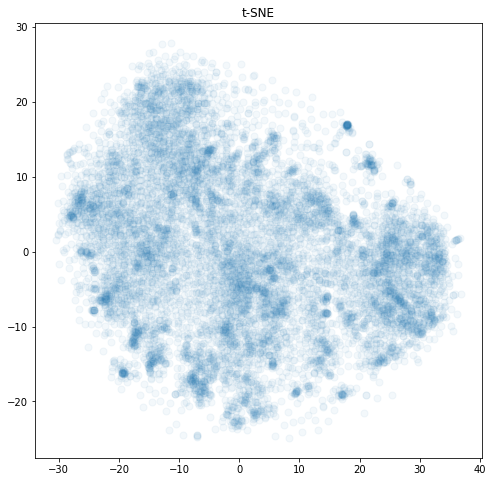

In [30]:
plt.figure(figsize=(8, 8))
plt.scatter(
    tsne_df[:, 0],
    tsne_df[:, 1],
    s=50, alpha=0.05
)
plt.title('t-SNE')

### Averaged vectors

In [31]:
tsne_transform = TSNE(n_components=2,
                      perplexity=50, verbose=1,
                      n_iter=10000, random_seed=42)
tsne_df = tsne_transform.fit_transform(np.array(trainDataVecs))

Initializing cuda handles... done.
KNN Computation... done.
Computing Pij matrix... done.
Initializing low dim points... done.
Initializing CUDA memory... done.
[Step 0] Avg. Gradient Norm: 1.40842e-05
[Step 10] Avg. Gradient Norm: 3.31504e-06
[Step 20] Avg. Gradient Norm: 1.91772e-07
[Step 30] Avg. Gradient Norm: 7.94075e-08
[Step 40] Avg. Gradient Norm: 1.16991e-07
[Step 50] Avg. Gradient Norm: 2.29826e-07
[Step 60] Avg. Gradient Norm: 4.99773e-07
[Step 70] Avg. Gradient Norm: 1.17718e-06
[Step 80] Avg. Gradient Norm: 2.97976e-06
[Step 90] Avg. Gradient Norm: 8.16383e-06
[Step 100] Avg. Gradient Norm: 2.39226e-05
[Step 110] Avg. Gradient Norm: 7.55303e-05
[Step 120] Avg. Gradient Norm: 0.00025234
[Step 130] Avg. Gradient Norm: 0.000890735
[Step 140] Avg. Gradient Norm: 0.00324936
[Step 150] Avg. Gradient Norm: 0.00977726
[Step 160] Avg. Gradient Norm: 0.00882512
[Step 170] Avg. Gradient Norm: 0.00153435
[Step 180] Avg. Gradient Norm: 0.000127541
[Step 190] Avg. Gradient Norm: 1.04066

[Step 1970] Avg. Gradient Norm: 0.00162862
[Step 1980] Avg. Gradient Norm: 0.00159256
[Step 1990] Avg. Gradient Norm: 0.00154257
[Step 2000] Avg. Gradient Norm: 0.00149276
[Step 2010] Avg. Gradient Norm: 0.00144834
[Step 2020] Avg. Gradient Norm: 0.00140636
[Step 2030] Avg. Gradient Norm: 0.00135932
[Step 2040] Avg. Gradient Norm: 0.00131539
[Step 2050] Avg. Gradient Norm: 0.00129129
[Step 2060] Avg. Gradient Norm: 0.00126816
[Step 2070] Avg. Gradient Norm: 0.00124467
[Step 2080] Avg. Gradient Norm: 0.0012102
[Step 2090] Avg. Gradient Norm: 0.00117533
[Step 2100] Avg. Gradient Norm: 0.00113606
[Step 2110] Avg. Gradient Norm: 0.00110432
[Step 2120] Avg. Gradient Norm: 0.00106865
[Step 2130] Avg. Gradient Norm: 0.00104627
[Step 2140] Avg. Gradient Norm: 0.00105661
[Step 2150] Avg. Gradient Norm: 0.00106779
[Step 2160] Avg. Gradient Norm: 0.00108356
[Step 2170] Avg. Gradient Norm: 0.00110291
[Step 2180] Avg. Gradient Norm: 0.00111326
[Step 2190] Avg. Gradient Norm: 0.00113142
[Step 2200] 

[Step 3860] Avg. Gradient Norm: 0.00243411
[Step 3870] Avg. Gradient Norm: 0.0024503
[Step 3880] Avg. Gradient Norm: 0.0024629
[Step 3890] Avg. Gradient Norm: 0.00247397
[Step 3900] Avg. Gradient Norm: 0.00251814
[Step 3910] Avg. Gradient Norm: 0.00298223
[Step 3920] Avg. Gradient Norm: 0.00242299
[Step 3930] Avg. Gradient Norm: 0.00190496
[Step 3940] Avg. Gradient Norm: 0.00154313
[Step 3950] Avg. Gradient Norm: 0.00133089
[Step 3960] Avg. Gradient Norm: 0.00118054
[Step 3970] Avg. Gradient Norm: 0.00104828
[Step 3980] Avg. Gradient Norm: 0.000946934
[Step 3990] Avg. Gradient Norm: 0.000879506
[Step 4000] Avg. Gradient Norm: 0.000819624
[Step 4010] Avg. Gradient Norm: 0.000773582
[Step 4020] Avg. Gradient Norm: 0.00075
[Step 4030] Avg. Gradient Norm: 0.000724242
[Step 4040] Avg. Gradient Norm: 0.000699431
[Step 4050] Avg. Gradient Norm: 0.000686879
[Step 4060] Avg. Gradient Norm: 0.000691326
[Step 4070] Avg. Gradient Norm: 0.000694101
[Step 4080] Avg. Gradient Norm: 0.000697276
[Step 

[Step 5750] Avg. Gradient Norm: 0.00067744
[Step 5760] Avg. Gradient Norm: 0.000667426
[Step 5770] Avg. Gradient Norm: 0.000662777
[Step 5780] Avg. Gradient Norm: 0.000677545
[Step 5790] Avg. Gradient Norm: 0.000684634
[Step 5800] Avg. Gradient Norm: 0.000671805
[Step 5810] Avg. Gradient Norm: 0.000665982
[Step 5820] Avg. Gradient Norm: 0.000657756
[Step 5830] Avg. Gradient Norm: 0.000648052
[Step 5840] Avg. Gradient Norm: 0.000643196
[Step 5850] Avg. Gradient Norm: 0.000644472
[Step 5860] Avg. Gradient Norm: 0.00066655
[Step 5870] Avg. Gradient Norm: 0.000687856
[Step 5880] Avg. Gradient Norm: 0.000670012
[Step 5890] Avg. Gradient Norm: 0.000654643
[Step 5900] Avg. Gradient Norm: 0.000653433
[Step 5910] Avg. Gradient Norm: 0.000657425
[Step 5920] Avg. Gradient Norm: 0.000651349
[Step 5930] Avg. Gradient Norm: 0.000651454
[Step 5940] Avg. Gradient Norm: 0.000651796
[Step 5950] Avg. Gradient Norm: 0.000680352
[Step 5960] Avg. Gradient Norm: 0.000698971
[Step 5970] Avg. Gradient Norm: 0.

[Step 7640] Avg. Gradient Norm: 0.000292371
[Step 7650] Avg. Gradient Norm: 0.000293935
[Step 7660] Avg. Gradient Norm: 0.000302232
[Step 7670] Avg. Gradient Norm: 0.000311339
[Step 7680] Avg. Gradient Norm: 0.000318175
[Step 7690] Avg. Gradient Norm: 0.000309224
[Step 7700] Avg. Gradient Norm: 0.000302651
[Step 7710] Avg. Gradient Norm: 0.000294484
[Step 7720] Avg. Gradient Norm: 0.000291192
[Step 7730] Avg. Gradient Norm: 0.000298919
[Step 7740] Avg. Gradient Norm: 0.000292856
[Step 7750] Avg. Gradient Norm: 0.000290277
[Step 7760] Avg. Gradient Norm: 0.000300643
[Step 7770] Avg. Gradient Norm: 0.000313396
[Step 7780] Avg. Gradient Norm: 0.000317888
[Step 7790] Avg. Gradient Norm: 0.000314752
[Step 7800] Avg. Gradient Norm: 0.000296015
[Step 7810] Avg. Gradient Norm: 0.000288323
[Step 7820] Avg. Gradient Norm: 0.0002858
[Step 7830] Avg. Gradient Norm: 0.000277912
[Step 7840] Avg. Gradient Norm: 0.000280403
[Step 7850] Avg. Gradient Norm: 0.00028789
[Step 7860] Avg. Gradient Norm: 0.0

[Step 9530] Avg. Gradient Norm: 0.000815926
[Step 9540] Avg. Gradient Norm: 0.000819402
[Step 9550] Avg. Gradient Norm: 0.000822867
[Step 9560] Avg. Gradient Norm: 0.000826651
[Step 9570] Avg. Gradient Norm: 0.00082512
[Step 9580] Avg. Gradient Norm: 0.000832921
[Step 9590] Avg. Gradient Norm: 0.000846123
[Step 9600] Avg. Gradient Norm: 0.000848706
[Step 9610] Avg. Gradient Norm: 0.000868883
[Step 9620] Avg. Gradient Norm: 0.000882687
[Step 9630] Avg. Gradient Norm: 0.000880677
[Step 9640] Avg. Gradient Norm: 0.000884876
[Step 9650] Avg. Gradient Norm: 0.000893695
[Step 9660] Avg. Gradient Norm: 0.000908497
[Step 9670] Avg. Gradient Norm: 0.000927064
[Step 9680] Avg. Gradient Norm: 0.000919908
[Step 9690] Avg. Gradient Norm: 0.00092323
[Step 9700] Avg. Gradient Norm: 0.000923839
[Step 9710] Avg. Gradient Norm: 0.000945506
[Step 9720] Avg. Gradient Norm: 0.000951165
[Step 9730] Avg. Gradient Norm: 0.000947972
[Step 9740] Avg. Gradient Norm: 0.000952629
[Step 9750] Avg. Gradient Norm: 0.

Text(0.5, 1.0, 't-SNE')

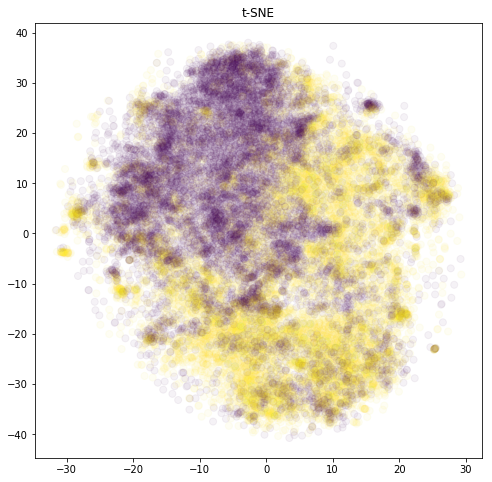

In [32]:
plt.figure(figsize=(8, 8))
plt.scatter(
    tsne_df[:, 0],
    tsne_df[:, 1],
    s=50, alpha=0.05, c=train_data['sentiment']
)
plt.title('t-SNE')

Doesn't look really obvious. Still, trying to clusterize...

### Model vectors

In [33]:
# !pip install git+https://github.com/src-d/kmcuda.git#subdirectory=src
from libKMCUDA import kmeans_cuda

Normalizing the vectors

In [34]:
model.init_sims()

2019-11-24 15:20:34,896 : INFO : precomputing L2-norms of word weight vectors


In [35]:
%%time
word_vectors = model.wv.vectors_norm
# The number of clusters value is kind of random
num_clusters = int(word_vectors.shape[0]/5)
centroids, assignments = kmeans_cuda(word_vectors, num_clusters,
                                     verbosity=1, seed=3, metric='cos')

reassignments threshold: 90
transposing the samples...
performing kmeans++...
done            
running Lloyd until reassignments drop below 994
iteration 1: 9042 reassignments
iteration 2: 603 reassignments
transposing the samples...
performing kmeans++...
done            
iteration 1: 1808 reassignments
iteration 2: 201 reassignments
iteration 3: 53 reassignments
iteration 4: 19 reassignments
transposing the samples...
refreshing Yinyang bounds...
iteration 3: 142 reassignments
iteration 4: 35 reassignments
CPU times: user 2.82 s, sys: 829 ms, total: 3.64 s
Wall time: 3.62 s


Looking at what's happening inside the assignments

In [36]:
for i in range(6):
    print('cluster #'+str(i))
    print(pd.Series(model.wv.index2word)[assignments==i])
    print('\n')

cluster #0
457         hit
1046       drop
1570      knock
1901     string
2942       toss
2970      smash
2975    scratch
3478       tail
4418     bounce
4662       pump
5110       roar
5645     snatch
5855       plug
6240      brick
7609      stall
7877       hurl
dtype: object


cluster #1
266     expect
574       hell
882     bother
1975      heck
dtype: object


cluster #2
3552    trademark
4211        flair
4319       wildly
8590    precision
8950      panache
dtype: object


cluster #3
520            theme
2954       essential
3170        relevant
3969        underlie
4628         preachy
7519        integral
7836    implications
8720      inherently
dtype: object


cluster #4
2501        expert
6630           bio
7611    specialist
dtype: object


cluster #5
1224     center
2062    revolve
3858     centre
dtype: object




In [37]:
# Create a Word / Index dictionary,
# mapping each vocabulary word to a cluster label       
word_centroid_map = dict(zip(model.wv.index2word, assignments))

These functions create a "bag of centroids" for each review. It is a numpy array of length equal to the number of clusters, each value corresponds to the number of entries in each cluster.

In [38]:
def zero_index(t, num_clusters):
    idx = np.array([word_centroid_map[x]
                    if x in word_centroid_map
                    else np.nan for x in t])
    counts = np.unique(idx[~np.isnan(idx)], return_counts=True)
    indexes = counts[0].astype(int)
    vals = counts[1]
    t_arr = np.zeros(num_clusters)
    t_arr[indexes] = vals
    return t_arr

In [39]:
def series_centroids(reviews, word_centroid_map, num_clusters):
    t_df = pd.DataFrame(reviews)
    t_df1 = t_df.iloc[:, 0].apply(zero_index, args=(num_clusters, ))
    return t_df1.values.tolist()

In [40]:
%%time
train_centroids1 = series_centroids(clean_train_reviews,
                                    word_centroid_map, num_clusters)
test_centroids1 = series_centroids(clean_test_reviews,
                                   word_centroid_map, num_clusters)

CPU times: user 1.76 s, sys: 16.4 ms, total: 1.78 s
Wall time: 1.78 s


In [41]:
forest = RandomForestClassifier(n_estimators=100,
                                n_jobs=-1, random_state=42)
print("Fitting a random forest to labeled training data...")
forest = forest.fit(train_centroids1, train_data["sentiment"])

Fitting a random forest to labeled training data...


In [42]:
roc_auc_score(test_data['sentiment'],
              forest.predict_proba(test_centroids1)[:,1])

0.9207755039931106

### Iterating over the number of clusters

In [43]:
np.random.seed(42)
kf = KFold(n_splits=5, random_state=42)

# word_vectors = model.wv.vectors
word_vectors = model.wv.vectors_norm
num_clusters = [int(word_vectors.shape[0] / i)
                for i in [2, 5, 10, 20, 50, 100, 200, 500]]

cv_scores = {}


for n in num_clusters:

    centroids, assignments = kmeans_cuda(word_vectors, n,
                                         verbosity=1, seed=3, metric='cos')
    word_centroid_map = dict(zip(model.wv.index2word, assignments))

    train_centroids = series_centroids(clean_train_reviews,
                                       word_centroid_map, n)

    print('CV scores: ')
    forest = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    cv = cross_val_score(forest, np.array(train_centroids),
                         train_data['sentiment'], scoring='roc_auc',
                         cv=kf.split(np.array(train_centroids),
                                     train_data['sentiment']),
                         n_jobs=-1, verbose=10)
    print(cv, end=' ')

    cv_scores[n] = np.mean(cv), np.std(cv)
    print('\n'+str(cv_scores[n])+'\n')


reassignments threshold: 90
transposing the samples...
performing kmeans++...
done            
running Lloyd until reassignments drop below 994
iteration 1: 9042 reassignments
iteration 2: 113 reassignments
transposing the samples...
performing kmeans++...
done            
iteration 1: 4521 reassignments
iteration 2: 519 reassignments
iteration 3: 139 reassignments
iteration 4: 71 reassignments
transposing the samples...
refreshing Yinyang bounds...
iteration 3: 16 reassignments
CV scores: 


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   43.8s remaining:  1.1min
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   44.4s remaining:   29.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   44.5s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   44.5s finished


[0.92526483 0.91952288 0.91833255 0.91498381 0.91120964] 
(0.9178627416869984, 0.004697225882785932)

reassignments threshold: 90
transposing the samples...
performing kmeans++...
done            
running Lloyd until reassignments drop below 994
iteration 1: 9042 reassignments
iteration 2: 603 reassignments
transposing the samples...
performing kmeans++...
done            
iteration 1: 1808 reassignments
iteration 2: 201 reassignments
iteration 3: 53 reassignments
iteration 4: 19 reassignments
transposing the samples...
refreshing Yinyang bounds...
iteration 3: 142 reassignments
iteration 4: 35 reassignments
CV scores: 


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   16.4s remaining:   24.7s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:   19.4s remaining:   12.9s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   19.4s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   19.4s finished


[0.92062481 0.91659759 0.91716717 0.91492768 0.91343982] 
(0.9165514144507153, 0.0024204273118161486)

reassignments threshold: 90
transposing the samples...
performing kmeans++...
done            
running Lloyd until reassignments drop below 994
iteration 1: 9042 reassignments
iteration 2: 1338 reassignments
iteration 3: 359 reassignments
transposing the samples...
performing kmeans++...
done            
iteration 1: 904 reassignments
iteration 2: 113 reassignments
iteration 3: 25 reassignments
iteration 4: 8 reassignments
transposing the samples...
refreshing Yinyang bounds...
iteration 4: 133 reassignments
iteration 5: 64 reassignments
CV scores: 


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.7s remaining:    4.0s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    2.7s remaining:    1.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.8s finished


[0.88599467 0.87530501 0.87247274 0.87399844 0.87215175] 
(0.8759845202411218, 0.005130927715323001)

reassignments threshold: 90
transposing the samples...
performing kmeans++...
done            
running Lloyd until reassignments drop below 994
[CV]  ................................................................
[CV] .................................... , score=0.911, total=  42.5s
[CV]  ................................................................
[CV] .................................... , score=0.911, total=  10.5s
[CV]  ................................................................
[CV] .................................... , score=0.903, total=   4.1s
[CV]  ................................................................
[CV] .................................... , score=0.875, total=   2.8s
iteration 1: 9042 reassignments
iteration 2: 2816 reassignments
iteration 3: 723 reassignments
transposing the samples...
performing kmeans++...
done            
iteration 1: 18 reassign

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[0.86475958 0.86348992 0.85226916 0.85136024 0.85384912] 
(0.8571456044163186, 0.005767843543042499)



[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    2.4s remaining:    3.6s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    2.4s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.5s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.5s finished


### Plotting train CV scores

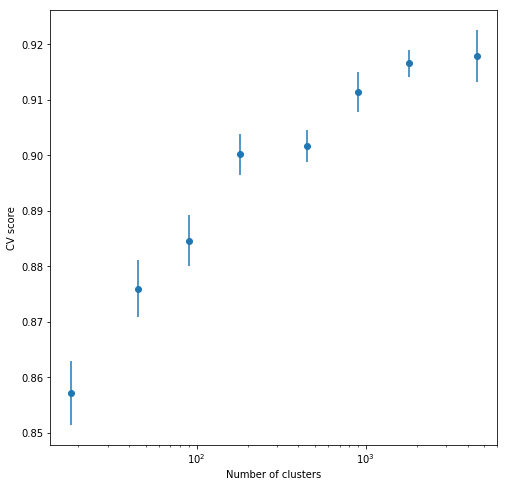

In [44]:
plt.figure(figsize=(8, 8))
plt.errorbar(cv_scores.keys(),
             np.array(list(cv_scores.values()))[:, 0],
             yerr=np.array(list(cv_scores.values()))[:, 1],
             fmt='o')
plt.xscale('log')
plt.xlabel('Number of clusters')
plt.ylabel('CV score')
plt.show()

### Evaluating test score for the top number of clusters

In [47]:
word_vectors = model.wv.vectors_norm
num_clusters = int(word_vectors.shape[0] / 5)

centroids, assignments = kmeans_cuda(word_vectors, num_clusters,
                                     verbosity=1, seed=3, metric='cos')
word_centroid_map = dict(zip(model.wv.index2word, assignments))
train_centroids = series_centroids(clean_train_reviews,
                                   word_centroid_map, num_clusters)
test_centroids = series_centroids(clean_test_reviews,
                                  word_centroid_map, num_clusters)

# Fit a random forest and extract predictions
forest = RandomForestClassifier(n_estimators=100, n_jobs=-1)

# Fitting the forest may take a few minutes
print("Fitting a random forest to labeled training data...")
forest = forest.fit(train_centroids, train_data["sentiment"])

roc_auc_score(test_data['sentiment'],
              forest.predict_proba(test_centroids)[:, 1])


reassignments threshold: 90
transposing the samples...
performing kmeans++...
done            
running Lloyd until reassignments drop below 994
iteration 1: 9042 reassignments
iteration 2: 603 reassignments
transposing the samples...
performing kmeans++...
done            
iteration 1: 1808 reassignments
iteration 2: 201 reassignments
iteration 3: 53 reassignments
iteration 4: 19 reassignments
transposing the samples...
refreshing Yinyang bounds...
iteration 3: 142 reassignments
iteration 4: 35 reassignments
Fitting a random forest to labeled training data...


0.9216151524912078

### Without clustering at all

In [48]:
word_vectors = model.wv.vectors_norm
num_clusters = word_vectors.shape[0]

assignments = np.array([i for i in range(len(word_vectors))])
word_centroid_map = dict(zip(model.wv.index2word, assignments))

train_centroids = series_centroids(clean_train_reviews,
                                   word_centroid_map, num_clusters)
test_centroids = series_centroids(clean_test_reviews,
                                  word_centroid_map, num_clusters)

# Fit a random forest and extract predictions
forest = RandomForestClassifier(n_estimators=100, n_jobs=-1)

# Fitting the forest may take a few minutes
print("Fitting a random forest to labeled training data...")
forest = forest.fit(train_centroids, train_data["sentiment"])

roc_auc_score(test_data['sentiment'],
              forest.predict_proba(test_centroids)[:, 1])


Fitting a random forest to labeled training data...


0.9217903626113444

Seems like clustering of the model vectors doesn't really help